<a href="https://www.kaggle.com/code/lalit7881/tech-salary-skills-dataset-eda?scriptVersionId=321197429" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mabubakrsiddiq/salary-and-skills-ds-what-factors-increases-salary/tech_salary_dataset.csv


## Loading dataset

In [2]:
df =pd.read_csv("/kaggle/input/datasets/mabubakrsiddiq/salary-and-skills-ds-what-factors-increases-salary/tech_salary_dataset.csv")

In [3]:
df.head()

,employee_id,first_name,last_name,age,gender,location,currency,primary_tech_field,job_title,employment_type,...,monthly_miscellaneous_usd,monthly_total_expenses_usd,annual_total_expenses_usd,annual_savings_usd,vacation_weeks,overtime_hours_per_month,months_since_last_promotion,num_previous_companies,job_satisfaction_score,is_actively_looking
0,EMP-00001,Emma,Johansson,32,Female,Remote (Global),USD,Backend Development,Platform Engineer,Full-time,...,417.44,5175.31,62103.72,6271.69,3,12.9,38,1,6,False
1,EMP-00002,Stephanie,Zhang,30,Female,"Seattle, USA",USD,QA & Testing,QA Engineer,Full-time,...,504.87,10082.84,120994.08,10151.16,4,6.5,26,1,4,False
2,EMP-00003,Raj,Lopez,32,Male,"Amsterdam, Netherlands",EUR,Backend Development,API Engineer,Full-time,...,377.88,8111.78,97341.36,4172.42,5,13.2,0,0,6,True
3,EMP-00004,Amelia,Taylor,31,Female,"London, UK",GBP,Database & Data Engineering,Analytics Engineer,Full-time,...,1140.39,23327.47,279929.64,19102.74,2,5.9,111,5,7,False
4,EMP-00005,Sophia,Gonzalez,42,Female,"Boston, USA",USD,Embedded Systems & IoT,Embedded Engineer,Full-time,...,844.73,11148.58,133782.96,3308.59,6,0.0,20,3,9,False


In [4]:
df.tail()

,employee_id,first_name,last_name,age,gender,location,currency,primary_tech_field,job_title,employment_type,...,monthly_miscellaneous_usd,monthly_total_expenses_usd,annual_total_expenses_usd,annual_savings_usd,vacation_weeks,overtime_hours_per_month,months_since_last_promotion,num_previous_companies,job_satisfaction_score,is_actively_looking
9995,EMP-09996,Natasha,Silva,38,Female,"Sydney, Australia",AUD,Product Management,Associate Product Manager,Full-time,...,1102.53,17158.18,205898.16,21516.12,3,7.3,52,2,7,False
9996,EMP-09997,Jacob,Chen,37,Male,"Boston, USA",USD,Full-Stack Development,Full Stack Developer,Full-time,...,833.94,14618.69,175424.28,34454.83,5,8.4,58,6,9,False
9997,EMP-09998,Kai,Muller,31,Non-Binary,"Hyderabad, India",INR,Full-Stack Development,Senior Software Engineer,Full-time,...,29.41,956.04,11472.48,2374.97,4,17.1,0,0,8,False
9998,EMP-09999,Hassan,Chia,32,Male,"Boston, USA",USD,Data Science & ML,Data Scientist,Full-time,...,1559.26,22335.50,268026.00,26685.96,4,14.3,78,2,6,False
9999,EMP-10000,Tyler,Costa,33,Male,"Seoul, South Korea",KRW,Frontend Development,UI Engineer,Part-time,...,773.86,11604.00,139248.00,12003.00,0,11.1,11,3,8,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   employee_id                  10000 non-null  object 
 1   first_name                   10000 non-null  object 
 2   last_name                    10000 non-null  object 
 3   age                          10000 non-null  int64  
 4   gender                       10000 non-null  object 
 5   location                     10000 non-null  object 
 6   currency                     10000 non-null  object 
 7   primary_tech_field           10000 non-null  object 
 8   job_title                    10000 non-null  object 
 9   employment_type              10000 non-null  object 
 10  work_arrangement             10000 non-null  object 
 11  experience_years_total       10000 non-null  float64
 12  experience_years_in_field    10000 non-null  float64
 13  education_level  

In [6]:
df.describe()

,age,experience_years_total,experience_years_in_field,num_skills,annual_salary_usd,monthly_salary_usd,hourly_rate_usd,annual_bonus_usd,bonus_percentage,equity_total_value_usd,...,monthly_childcare_usd,monthly_miscellaneous_usd,monthly_total_expenses_usd,annual_total_expenses_usd,annual_savings_usd,vacation_weeks,overtime_hours_per_month,months_since_last_promotion,num_previous_companies,job_satisfaction_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,...,10000.000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,31.637600,5.717070,4.019440,5.494200,171786.241744,14315.520181,91.601258,12363.473986,7.214300,28710.88860,...,916.206,818.562067,14148.267573,169779.210876,16530.105659,3.561300,10.581700,34.515400,1.629600,6.974100
std,6.856892,3.689415,2.823968,1.716176,72550.937998,6045.911530,45.335040,10863.881829,5.159558,100995.44362,...,1062.339,477.180884,7668.022002,92016.264021,10854.098074,1.543464,7.590467,32.959976,1.539364,2.157428
min,18.000000,0.500000,0.500000,3.000000,19846.270000,1653.860000,9.540000,0.000000,0.000000,0.00000,...,0.000,20.650000,424.070000,5088.840000,-4103.200000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,2.800000,1.800000,4.000000,121355.045000,10112.925000,61.190000,2282.800000,5.000000,0.00000,...,0.000,497.502500,9118.967500,109427.610000,8731.762500,2.000000,4.500000,8.000000,0.000000,6.000000
50%,32.000000,5.500000,3.600000,5.000000,167055.180000,13921.265000,85.295000,11302.280000,8.000000,0.00000,...,0.000,756.215000,13336.920000,160043.040000,14228.585000,4.000000,10.100000,26.000000,1.000000,7.000000
75%,36.000000,8.200000,5.700000,7.000000,216939.867500,18078.325000,113.770000,18781.787500,10.000000,9773.00000,...,1800.000,1087.377500,18536.777500,222441.330000,21807.995000,5.000000,15.700000,52.000000,2.000000,9.000000
max,58.000000,19.600000,17.800000,8.000000,479033.820000,39919.490000,373.060000,81019.780000,20.000000,995997.00000,...,3600.000,3868.360000,52337.650000,628051.800000,86728.360000,6.000000,54.100000,224.000000,10.000000,10.000000


In [7]:
df.isnull().sum()

employee_id                       0
first_name                        0
last_name                         0
age                               0
gender                            0
location                          0
currency                          0
primary_tech_field                0
job_title                         0
employment_type                   0
work_arrangement                  0
experience_years_total            0
experience_years_in_field         0
education_level                   0
languages_spoken                  0
skills                            0
primary_skill                     0
num_skills                        0
certifications                 4508
company_size                      0
annual_salary_usd                 0
monthly_salary_usd                0
hourly_rate_usd                   0
annual_bonus_usd                  0
bonus_percentage                  0
has_equity                        0
equity_total_value_usd            0
equity_vesting_years        

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['employee_id', 'first_name', 'last_name', 'age', 'gender', 'location',
       'currency', 'primary_tech_field', 'job_title', 'employment_type',
       'work_arrangement', 'experience_years_total',
       'experience_years_in_field', 'education_level', 'languages_spoken',
       'skills', 'primary_skill', 'num_skills', 'certifications',
       'company_size', 'annual_salary_usd', 'monthly_salary_usd',
       'hourly_rate_usd', 'annual_bonus_usd', 'bonus_percentage', 'has_equity',
       'equity_total_value_usd', 'equity_vesting_years',
       'effective_tax_rate_pct', 'annual_tax_usd', 'annual_net_salary_usd',
       'monthly_net_salary_usd', 'monthly_housing_usd',
       'monthly_transportation_usd', 'monthly_food_usd',
       'monthly_utilities_usd', 'monthly_healthcare_usd',
       'monthly_entertainment_usd', 'monthly_education_loan_usd',
       'monthly_childcare_usd', 'monthly_miscellaneous_usd',
       'monthly_total_expenses_usd', 'annual_total_expenses_usd',
       'annu

In [10]:
df.dtypes

employee_id                     object
first_name                      object
last_name                       object
age                              int64
gender                          object
location                        object
currency                        object
primary_tech_field              object
job_title                       object
employment_type                 object
work_arrangement                object
experience_years_total         float64
experience_years_in_field      float64
education_level                 object
languages_spoken                object
skills                          object
primary_skill                   object
num_skills                       int64
certifications                  object
company_size                    object
annual_salary_usd              float64
monthly_salary_usd             float64
hourly_rate_usd                float64
annual_bonus_usd               float64
bonus_percentage                 int64
has_equity               

In [11]:
df.shape

(10000, 50)

In [12]:
df.nunique()

employee_id                    10000
first_name                       110
last_name                         74
age                               40
gender                             4
location                          19
currency                          10
primary_tech_field                14
job_title                         78
employment_type                    4
work_arrangement                   4
experience_years_total           182
experience_years_in_field        158
education_level                    6
languages_spoken                1302
skills                          9915
primary_skill                    133
num_skills                         6
certifications                   677
company_size                       5
annual_salary_usd               9998
monthly_salary_usd              9966
hourly_rate_usd                 7245
annual_bonus_usd                7543
bonus_percentage                   7
has_equity                         2
equity_total_value_usd          4604
e

## EDA

In [13]:
import plotly.express as px

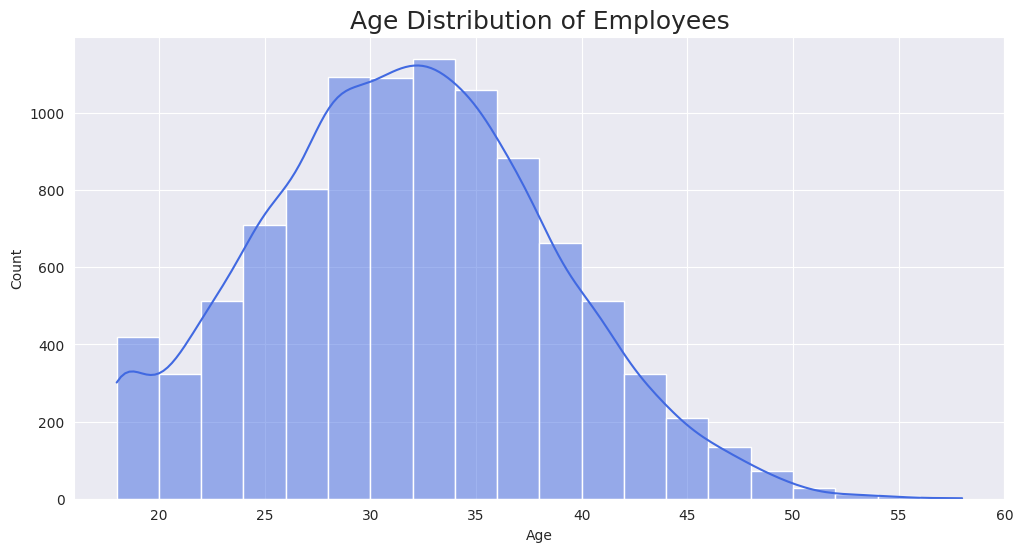

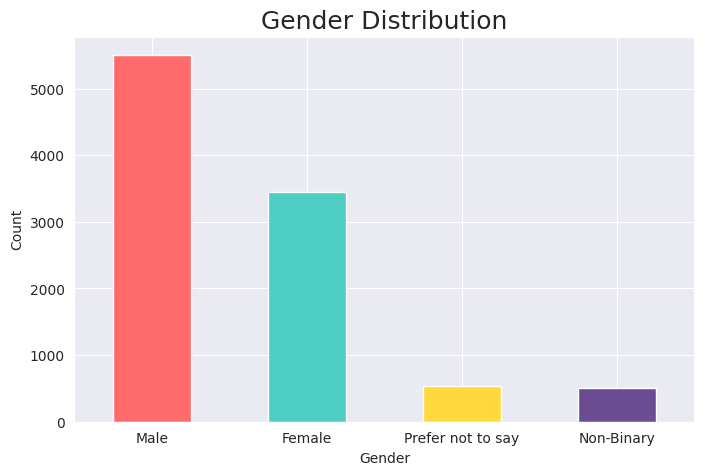

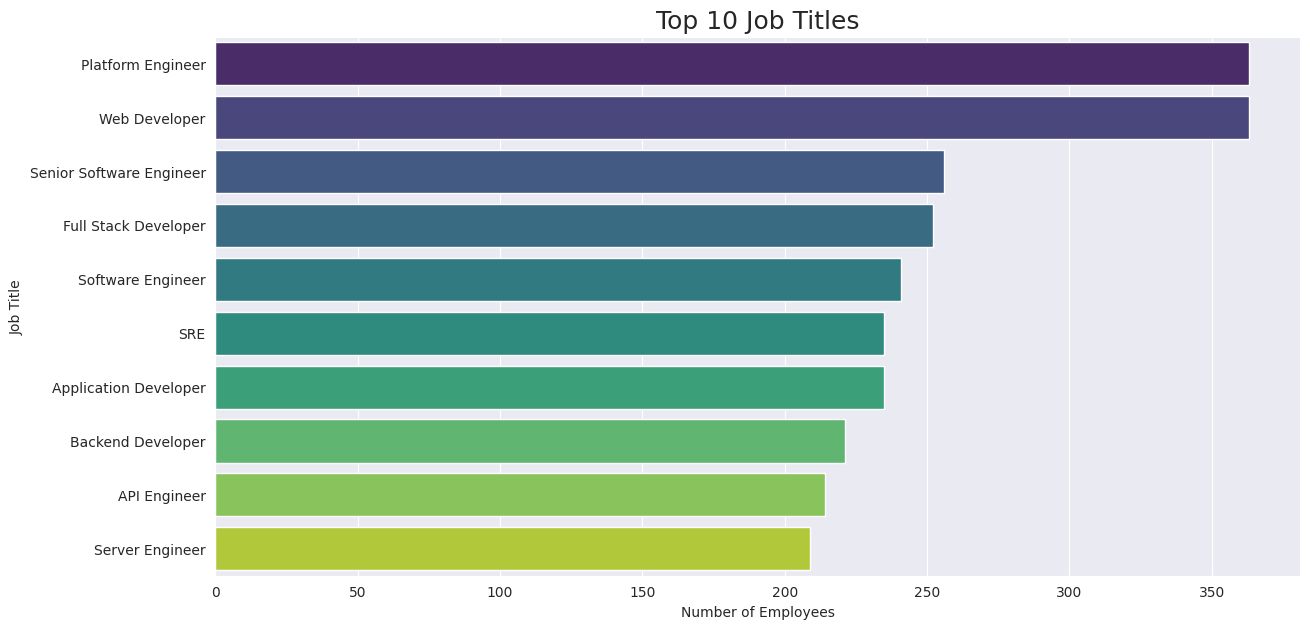

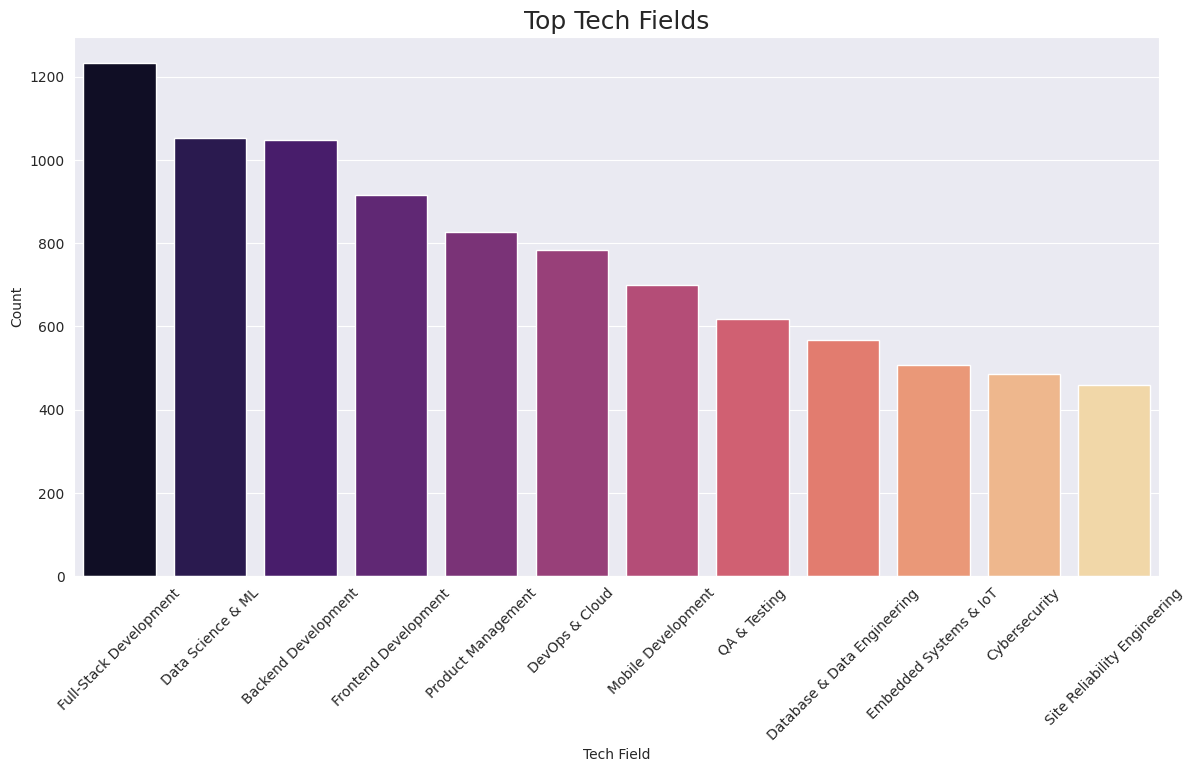

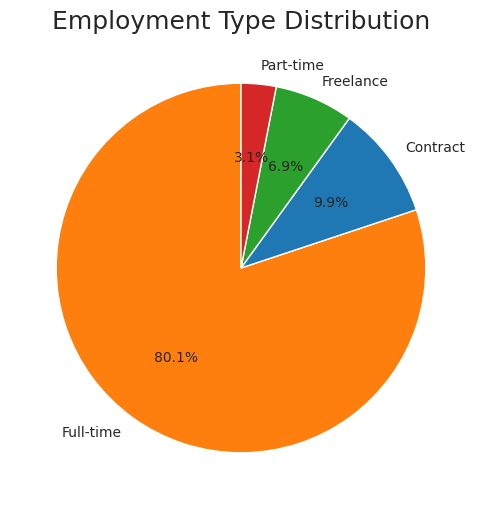

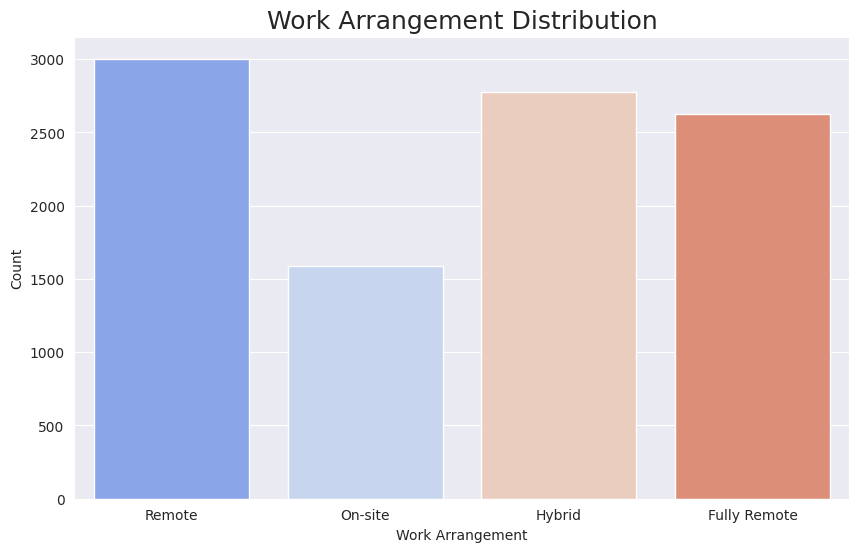

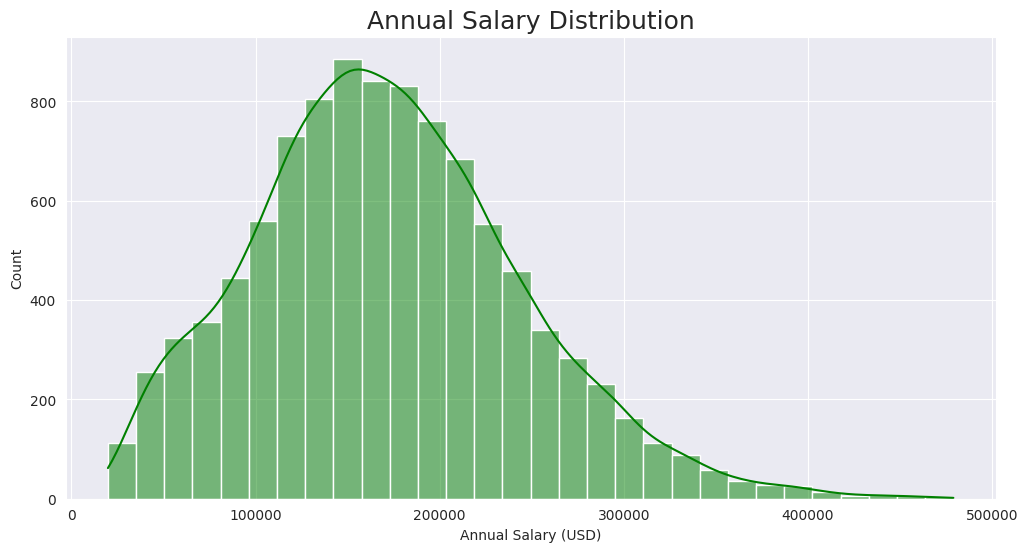

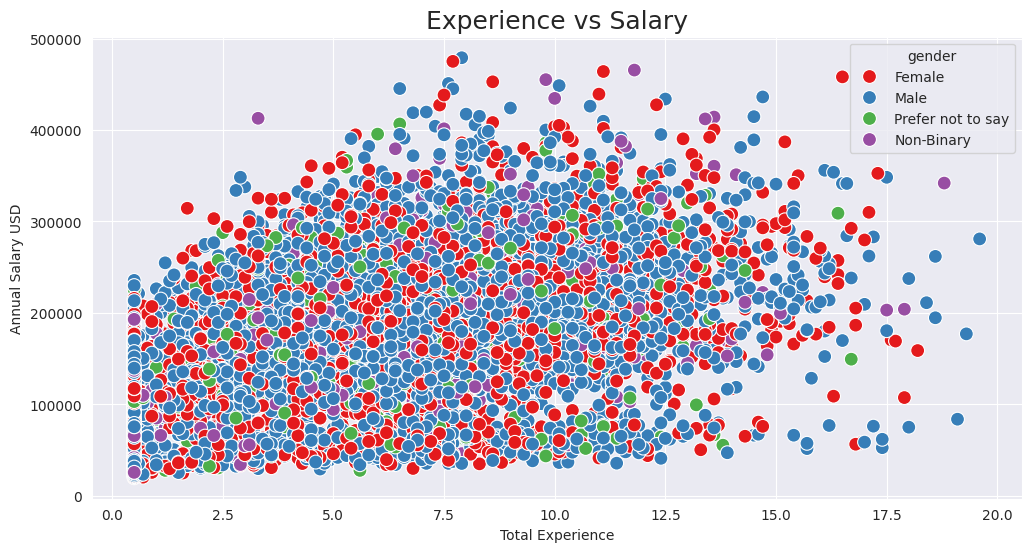

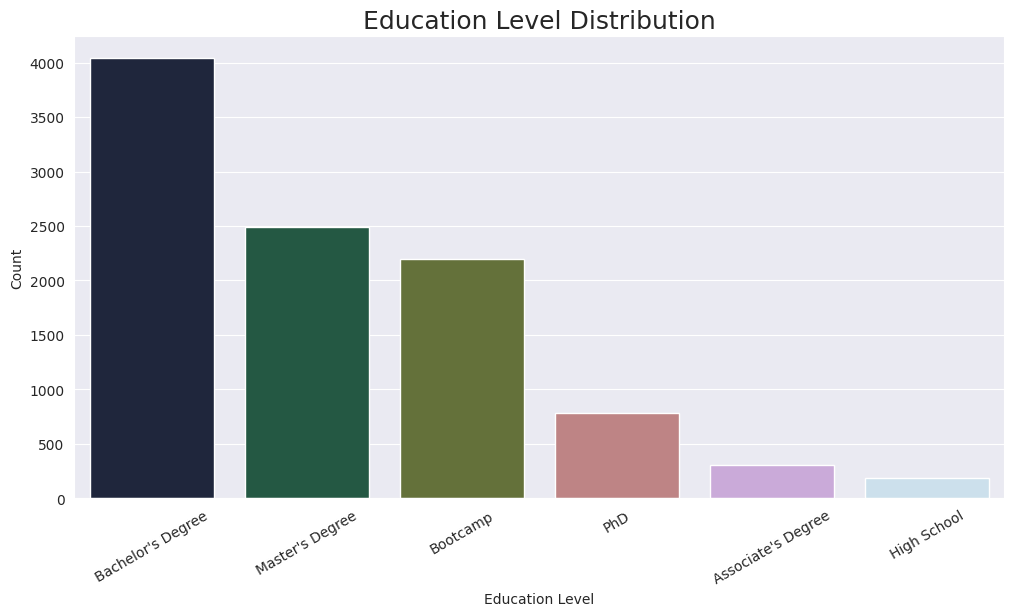

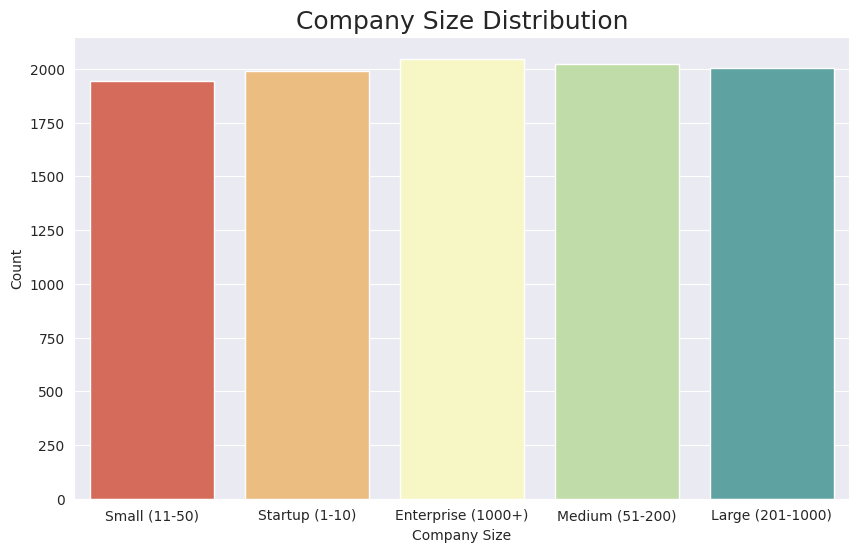

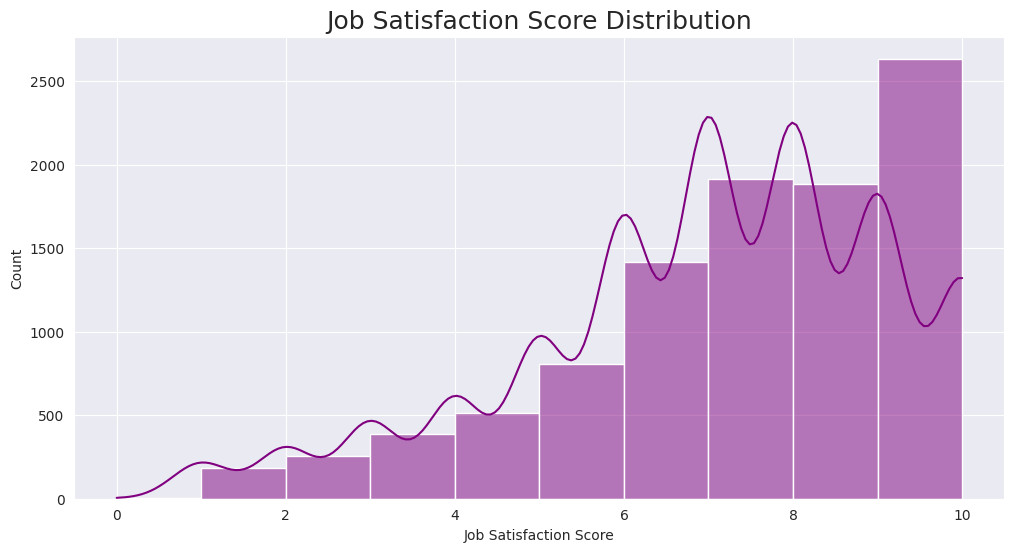

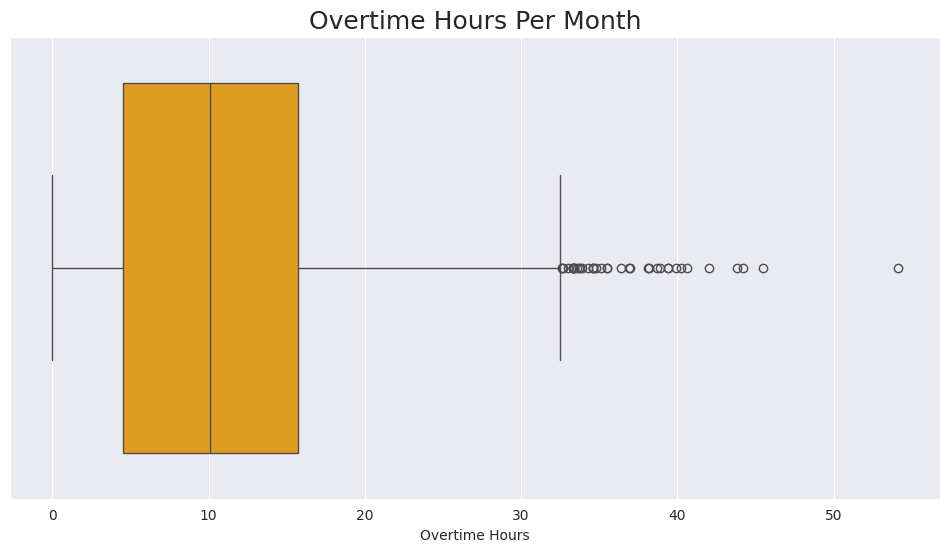

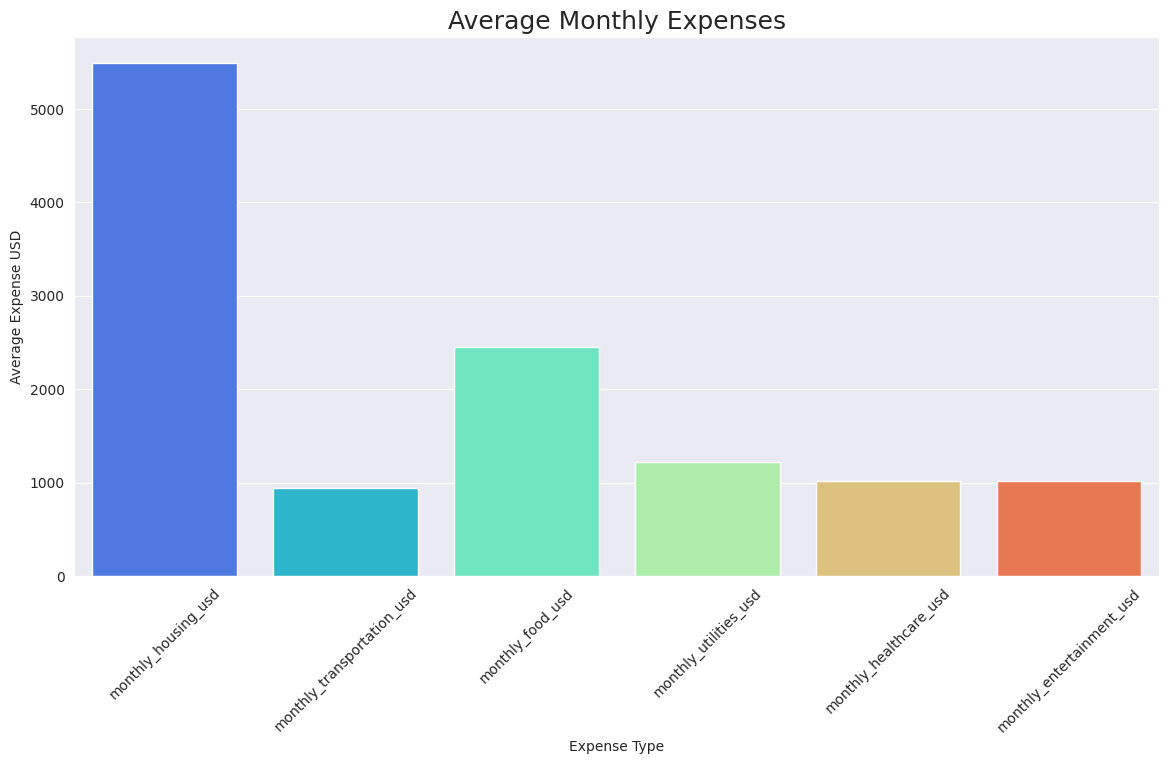

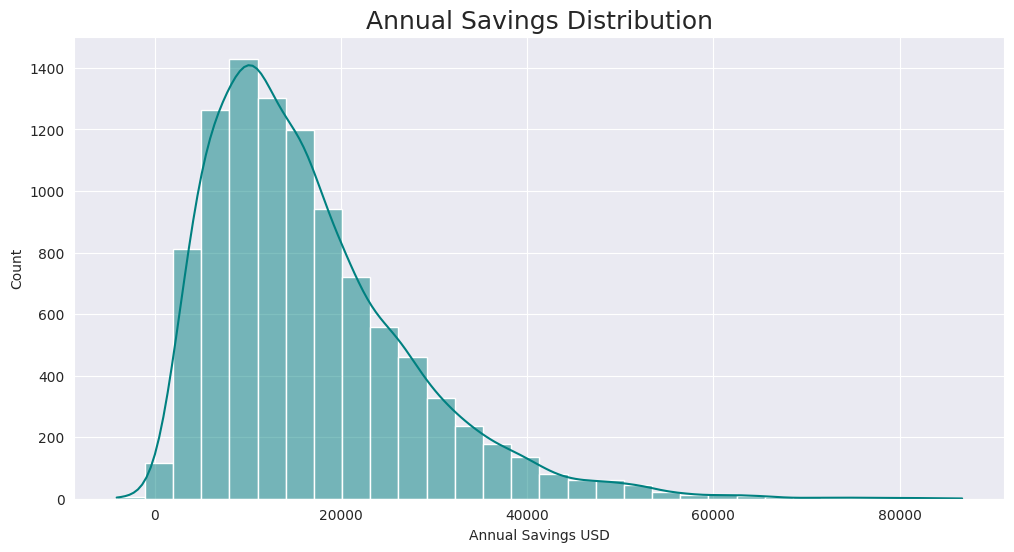

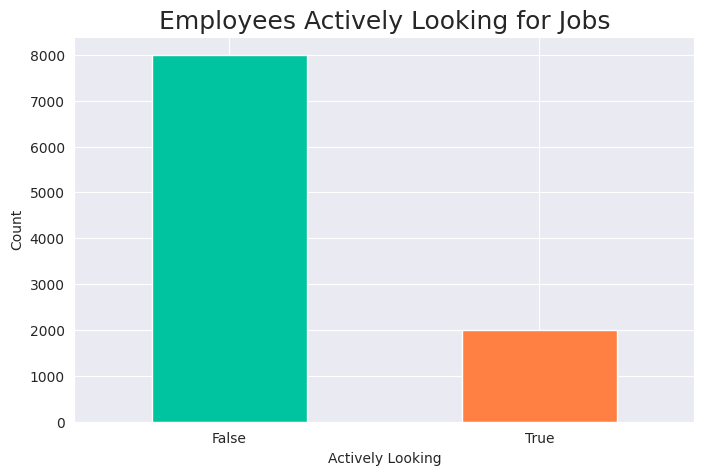

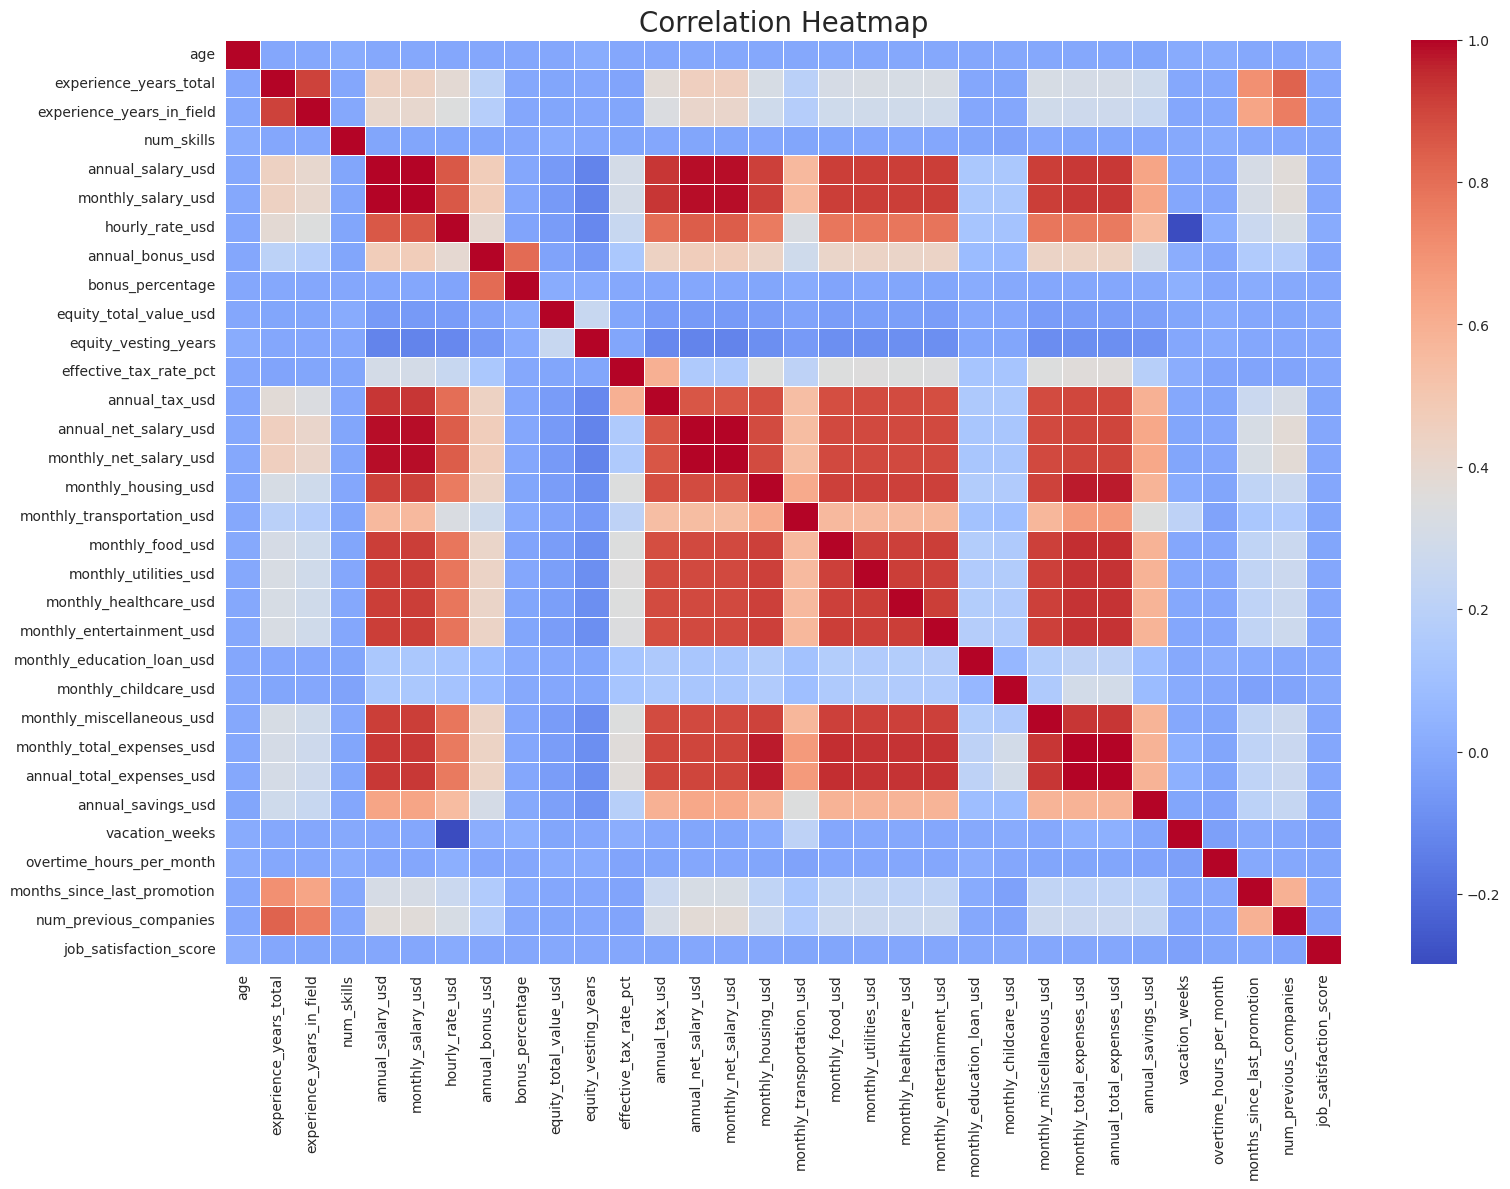

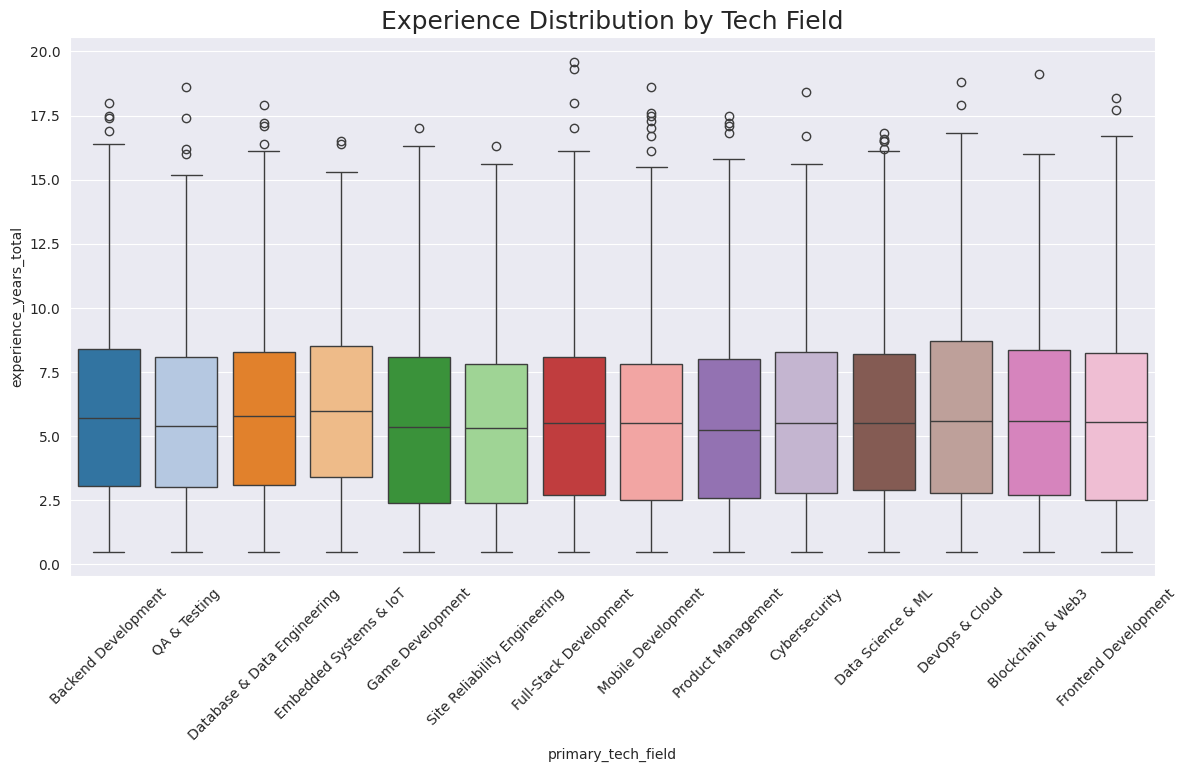

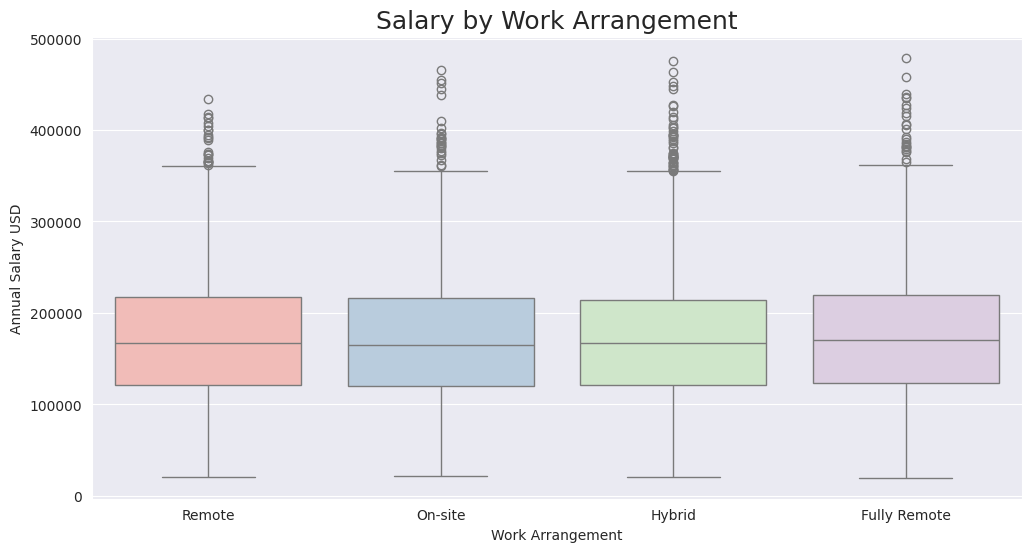

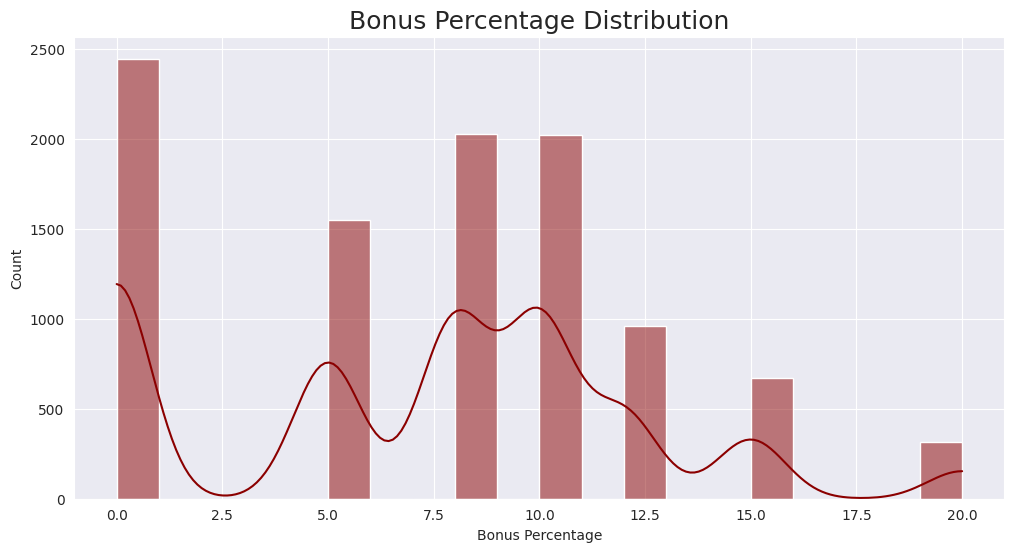

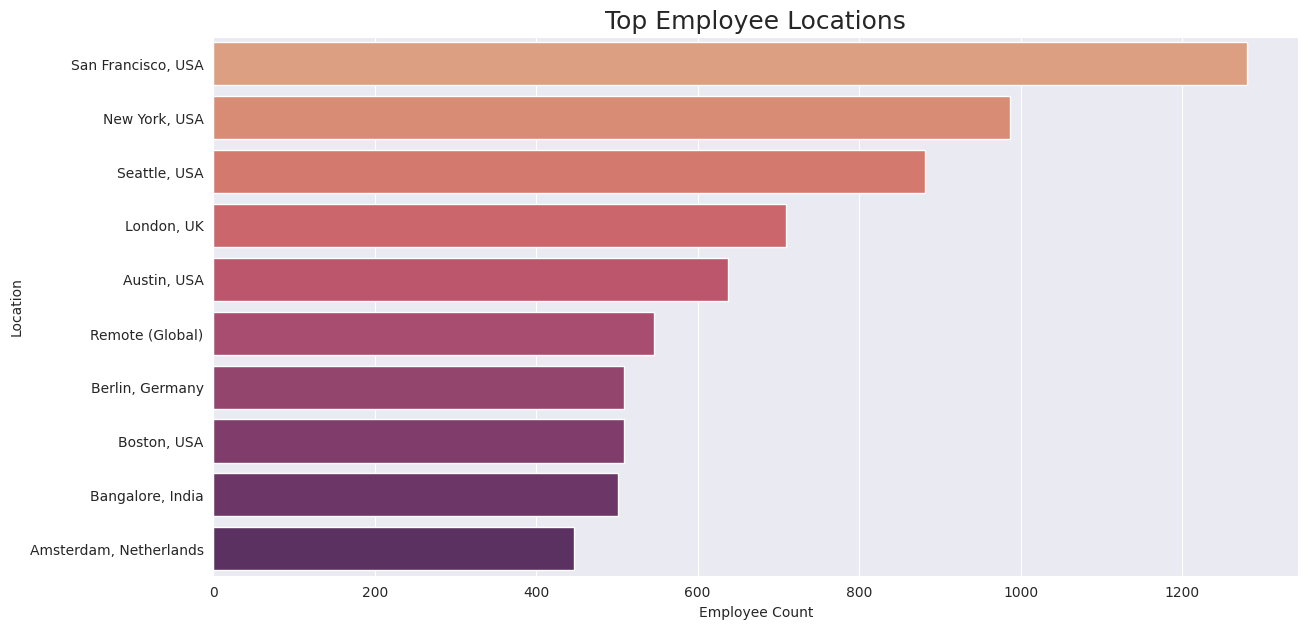

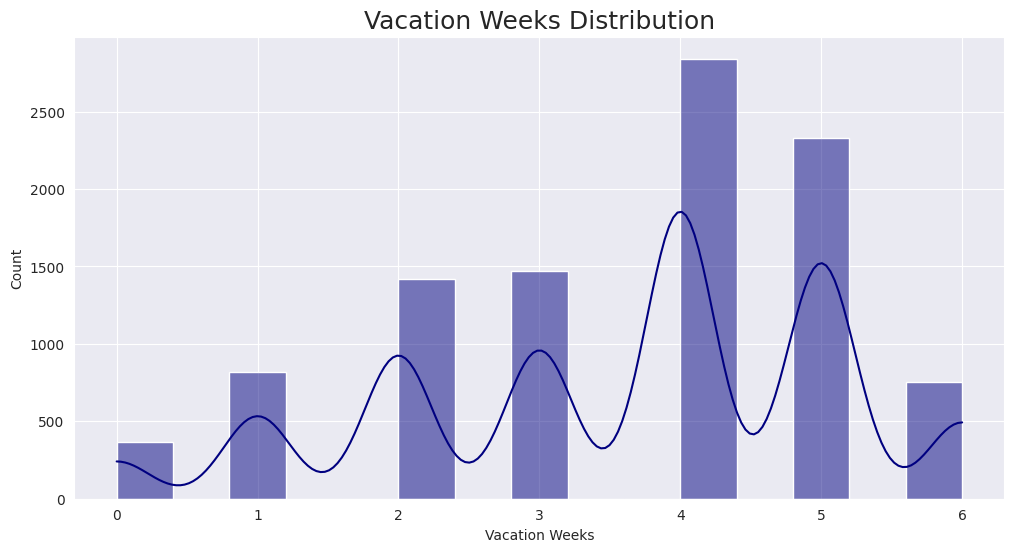

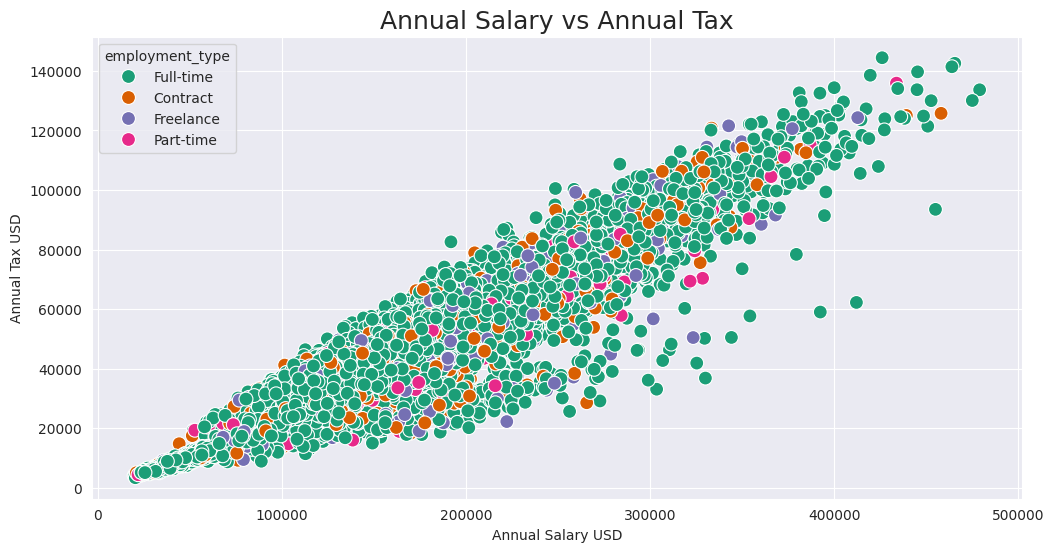

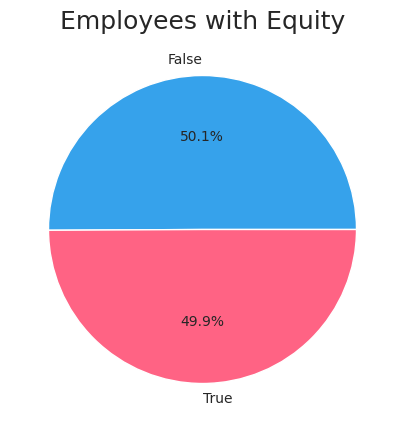

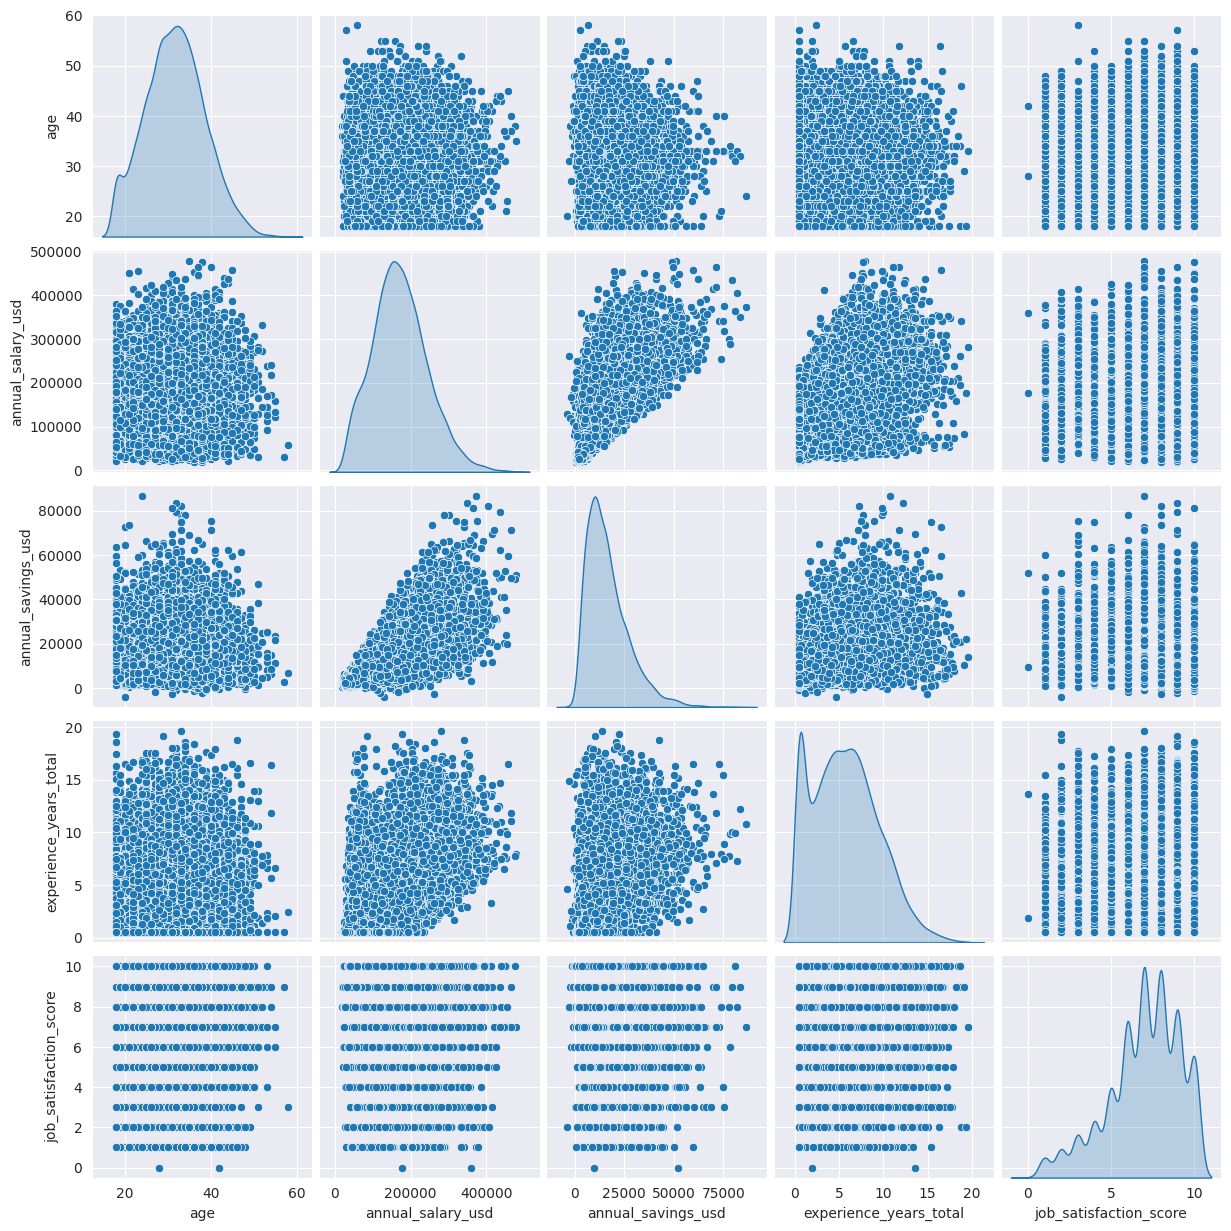

All visualizations completed successfully.


In [14]:
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12,6)

# ==========================================
# 1. AGE DISTRIBUTION
# ==========================================

plt.figure(figsize=(12,6))
sns.histplot(
    df['age'],
    bins=20,
    kde=True,
    color='royalblue'
)

plt.title("Age Distribution of Employees", fontsize=18)
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# ==========================================
# 2. GENDER DISTRIBUTION
# ==========================================

plt.figure(figsize=(8,5))

gender_colors = ['#FF6B6B', '#4ECDC4', '#FFD93D', '#6A4C93']

df['gender'].value_counts().plot(
    kind='bar',
    color=gender_colors
)

plt.title("Gender Distribution", fontsize=18)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# ==========================================
# 3. TOP JOB TITLES
# ==========================================

top_jobs = df['job_title'].value_counts().head(10)

plt.figure(figsize=(14,7))

sns.barplot(
    x=top_jobs.values,
    y=top_jobs.index,
    palette='viridis'
)

plt.title("Top 10 Job Titles", fontsize=18)
plt.xlabel("Number of Employees")
plt.ylabel("Job Title")
plt.show()

# ==========================================
# 4. PRIMARY TECH FIELD DISTRIBUTION
# ==========================================

plt.figure(figsize=(14,7))

tech_field = df['primary_tech_field'].value_counts().head(12)

sns.barplot(
    x=tech_field.index,
    y=tech_field.values,
    palette='magma'
)

plt.title("Top Tech Fields", fontsize=18)
plt.xlabel("Tech Field")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# 5. EMPLOYMENT TYPE ANALYSIS
# ==========================================

plt.figure(figsize=(10,6))

employment_colors = ['#ff7f0e', '#1f77b4', '#2ca02c', '#d62728']

df['employment_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=employment_colors,
    startangle=90
)

plt.title("Employment Type Distribution", fontsize=18)
plt.ylabel("")
plt.show()

# ==========================================
# 6. WORK ARRANGEMENT ANALYSIS
# ==========================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='work_arrangement',
    palette='coolwarm'
)

plt.title("Work Arrangement Distribution", fontsize=18)
plt.xlabel("Work Arrangement")
plt.ylabel("Count")
plt.show()

# ==========================================
# 7. SALARY DISTRIBUTION
# ==========================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['annual_salary_usd'],
    bins=30,
    kde=True,
    color='green'
)

plt.title("Annual Salary Distribution", fontsize=18)
plt.xlabel("Annual Salary (USD)")
plt.ylabel("Count")
plt.show()

# ==========================================
# 8. EXPERIENCE VS SALARY
# ==========================================

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='experience_years_total',
    y='annual_salary_usd',
    hue='gender',
    palette='Set1',
    s=100
)

plt.title("Experience vs Salary", fontsize=18)
plt.xlabel("Total Experience")
plt.ylabel("Annual Salary USD")
plt.show()

# ==========================================
# 9. EDUCATION LEVEL ANALYSIS
# ==========================================

plt.figure(figsize=(12,6))

edu_counts = df['education_level'].value_counts()

sns.barplot(
    x=edu_counts.index,
    y=edu_counts.values,
    palette='cubehelix'
)

plt.title("Education Level Distribution", fontsize=18)
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

# ==========================================
# 10. COMPANY SIZE DISTRIBUTION
# ==========================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='company_size',
    palette='Spectral'
)

plt.title("Company Size Distribution", fontsize=18)
plt.xlabel("Company Size")
plt.ylabel("Count")
plt.show()

# ==========================================
# 11. JOB SATISFACTION SCORE
# ==========================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['job_satisfaction_score'],
    bins=10,
    kde=True,
    color='purple'
)

plt.title("Job Satisfaction Score Distribution", fontsize=18)
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Count")
plt.show()

# ==========================================
# 12. OVERTIME HOURS ANALYSIS
# ==========================================

plt.figure(figsize=(12,6))

sns.boxplot(
    x=df['overtime_hours_per_month'],
    color='orange'
)

plt.title("Overtime Hours Per Month", fontsize=18)
plt.xlabel("Overtime Hours")
plt.show()

# ==========================================
# 13. MONTHLY EXPENSES ANALYSIS
# ==========================================

expense_cols = [
    'monthly_housing_usd',
    'monthly_transportation_usd',
    'monthly_food_usd',
    'monthly_utilities_usd',
    'monthly_healthcare_usd',
    'monthly_entertainment_usd'
]

avg_expenses = df[expense_cols].mean()

plt.figure(figsize=(14,7))

sns.barplot(
    x=avg_expenses.index,
    y=avg_expenses.values,
    palette='rainbow'
)

plt.title("Average Monthly Expenses", fontsize=18)
plt.xlabel("Expense Type")
plt.ylabel("Average Expense USD")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# 14. SAVINGS ANALYSIS
# ==========================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['annual_savings_usd'],
    bins=30,
    kde=True,
    color='teal'
)

plt.title("Annual Savings Distribution", fontsize=18)
plt.xlabel("Annual Savings USD")
plt.ylabel("Count")
plt.show()

# ==========================================
# 15. ACTIVE JOB SEEKERS
# ==========================================

plt.figure(figsize=(8,5))

active_colors = ['#00C49F', '#FF8042']

df['is_actively_looking'].value_counts().plot(
    kind='bar',
    color=active_colors
)

plt.title("Employees Actively Looking for Jobs", fontsize=18)
plt.xlabel("Actively Looking")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# ==========================================
# 16. CORRELATION HEATMAP
# ==========================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(18,12))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=20)
plt.show()

# ==========================================
# 17. EXPERIENCE BY TECH FIELD
# ==========================================

plt.figure(figsize=(14,7))

sns.boxplot(
    data=df,
    x='primary_tech_field',
    y='experience_years_total',
    palette='tab20'
)

plt.title("Experience Distribution by Tech Field", fontsize=18)
plt.xticks(rotation=45)
plt.show()

# ==========================================
# 18. SALARY BY WORK ARRANGEMENT
# ==========================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='work_arrangement',
    y='annual_salary_usd',
    palette='Pastel1'
)

plt.title("Salary by Work Arrangement", fontsize=18)
plt.xlabel("Work Arrangement")
plt.ylabel("Annual Salary USD")
plt.show()

# ==========================================
# 19. BONUS PERCENTAGE DISTRIBUTION
# ==========================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['bonus_percentage'],
    bins=20,
    kde=True,
    color='darkred'
)

plt.title("Bonus Percentage Distribution", fontsize=18)
plt.xlabel("Bonus Percentage")
plt.ylabel("Count")
plt.show()

# ==========================================
# 20. INTERACTIVE PLOTLY VISUALIZATION
# ==========================================

fig = px.scatter(
    df,
    x='experience_years_total',
    y='annual_salary_usd',
    color='work_arrangement',
    size='annual_bonus_usd',
    hover_data=['job_title', 'primary_tech_field'],
    title='Interactive Experience vs Salary Analysis'
)

fig.show()

# ==========================================
# 21. TOP LOCATIONS
# ==========================================

top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(14,7))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index,
    palette='flare'
)

plt.title("Top Employee Locations", fontsize=18)
plt.xlabel("Employee Count")
plt.ylabel("Location")
plt.show()

# ==========================================
# 22. VACATION WEEKS ANALYSIS
# ==========================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['vacation_weeks'],
    bins=15,
    kde=True,
    color='navy'
)

plt.title("Vacation Weeks Distribution", fontsize=18)
plt.xlabel("Vacation Weeks")
plt.ylabel("Count")
plt.show()

# ==========================================
# 23. TAX VS SALARY
# ==========================================

plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='annual_salary_usd',
    y='annual_tax_usd',
    hue='employment_type',
    palette='Dark2',
    s=100
)

plt.title("Annual Salary vs Annual Tax", fontsize=18)
plt.xlabel("Annual Salary USD")
plt.ylabel("Annual Tax USD")
plt.show()

# ==========================================
# 24. EQUITY ANALYSIS
# ==========================================

equity_counts = df['has_equity'].value_counts()

plt.figure(figsize=(8,5))

equity_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#36A2EB', '#FF6384']
)

plt.title("Employees with Equity", fontsize=18)
plt.ylabel("")
plt.show()

# ==========================================
# 25. PAIRPLOT
# ==========================================

selected_cols = [
    'age',
    'annual_salary_usd',
    'annual_savings_usd',
    'experience_years_total',
    'job_satisfaction_score'
]

sns.pairplot(
    df[selected_cols],
    diag_kind='kde'
)

plt.show()

# ==========================================
# END OF VISUALIZATION PROJECT
# ==========================================

print("All visualizations completed successfully.")

## Feature engineering

Dataset Shape : (10000, 50)

Columns:

Index(['employee_id', 'first_name', 'last_name', 'age', 'gender', 'location',
       'currency', 'primary_tech_field', 'job_title', 'employment_type',
       'work_arrangement', 'experience_years_total',
       'experience_years_in_field', 'education_level', 'languages_spoken',
       'skills', 'primary_skill', 'num_skills', 'certifications',
       'company_size', 'annual_salary_usd', 'monthly_salary_usd',
       'hourly_rate_usd', 'annual_bonus_usd', 'bonus_percentage', 'has_equity',
       'equity_total_value_usd', 'equity_vesting_years',
       'effective_tax_rate_pct', 'annual_tax_usd', 'annual_net_salary_usd',
       'monthly_net_salary_usd', 'monthly_housing_usd',
       'monthly_transportation_usd', 'monthly_food_usd',
       'monthly_utilities_usd', 'monthly_healthcare_usd',
       'monthly_entertainment_usd', 'monthly_education_loan_usd',
       'monthly_childcare_usd', 'monthly_miscellaneous_usd',
       'monthly_total_expenses_usd', 'a

<Figure size 1200x800 with 0 Axes>

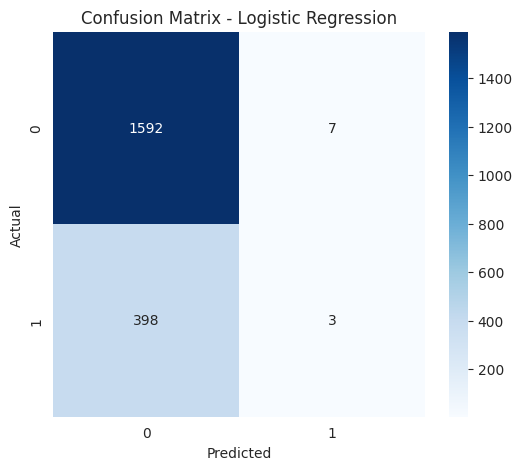



MODEL : Decision Tree

Accuracy Score : 0.7920
ROC AUC Score  : 0.5207

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.99      0.88      1599
           1       0.11      0.00      0.01       401

    accuracy                           0.79      2000
   macro avg       0.45      0.50      0.45      2000
weighted avg       0.66      0.79      0.71      2000



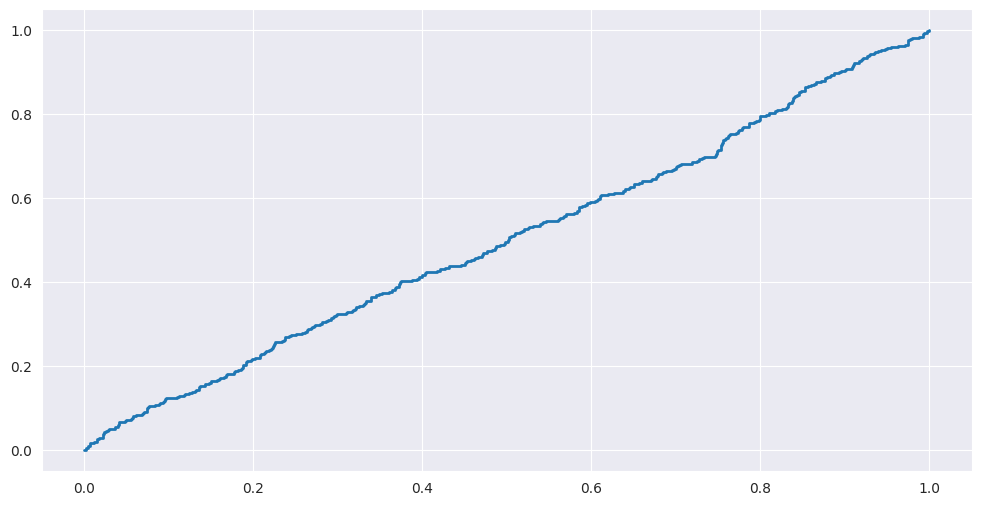

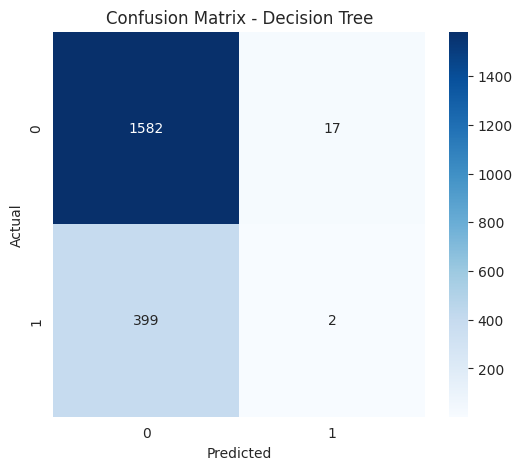



MODEL : Random Forest

Accuracy Score : 0.7995
ROC AUC Score  : 0.5048

Classification Report:

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1599
           1       0.00      0.00      0.00       401

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



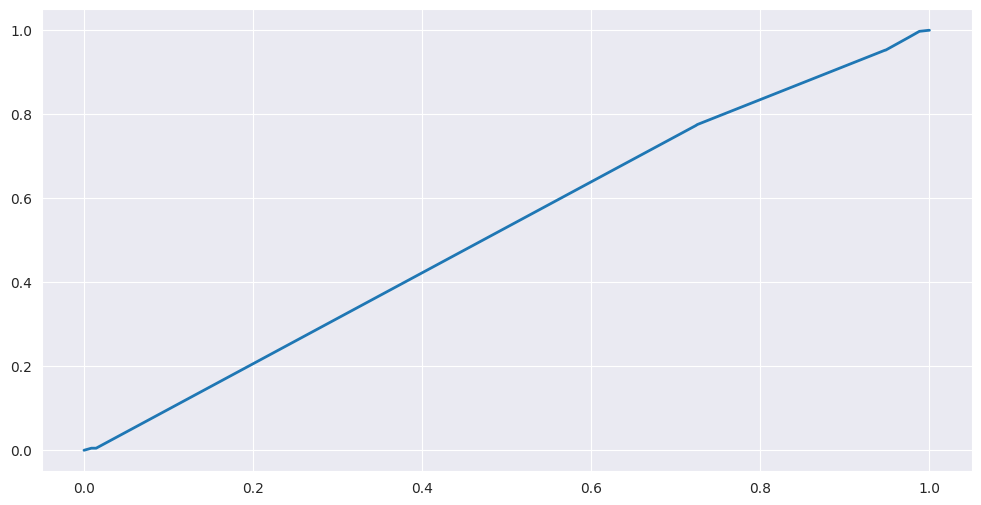

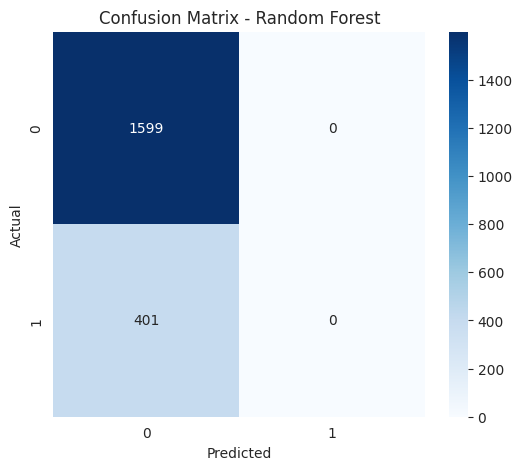



MODEL : Gradient Boosting

Accuracy Score : 0.7995
ROC AUC Score  : 0.5130

Classification Report:

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1599
           1       0.00      0.00      0.00       401

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



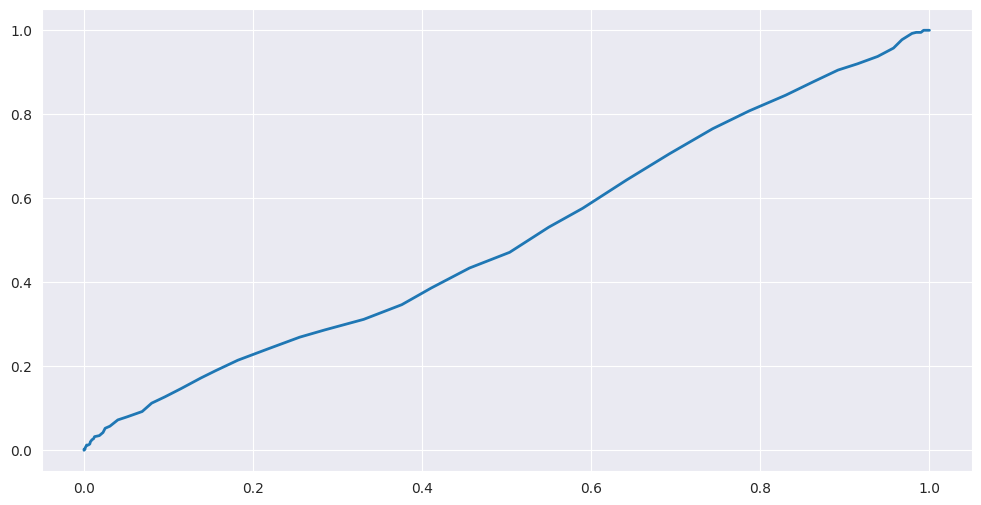

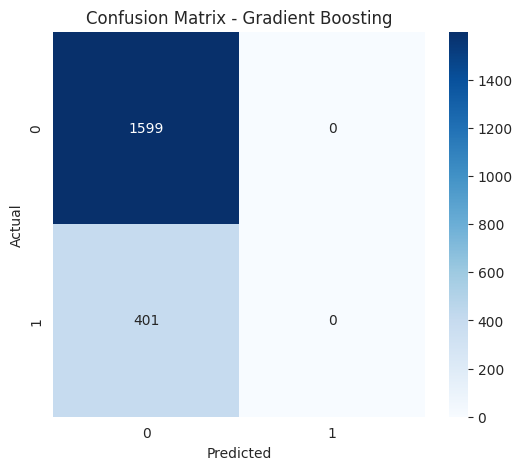



MODEL : KNN

Accuracy Score : 0.7575
ROC AUC Score  : 0.4620

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.93      0.86      1599
           1       0.17      0.05      0.08       401

    accuracy                           0.76      2000
   macro avg       0.48      0.49      0.47      2000
weighted avg       0.67      0.76      0.70      2000



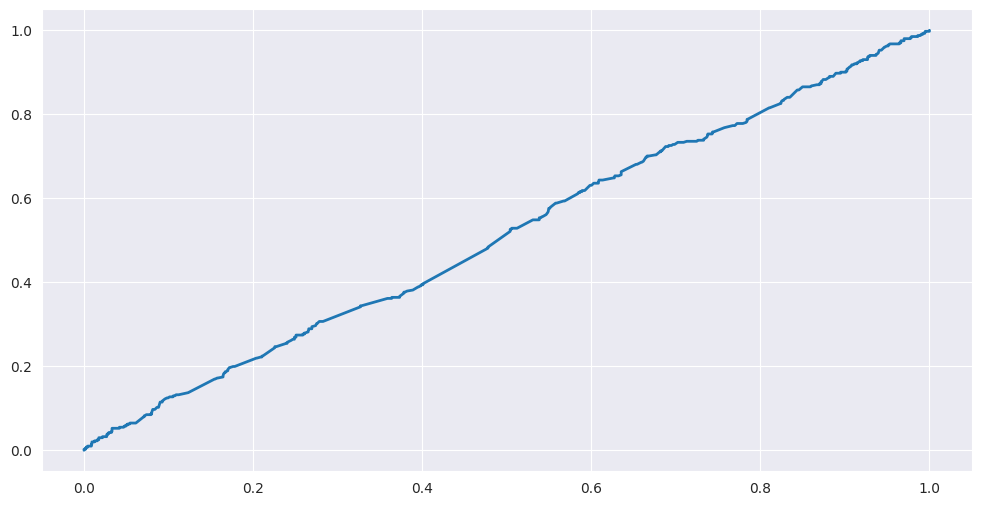

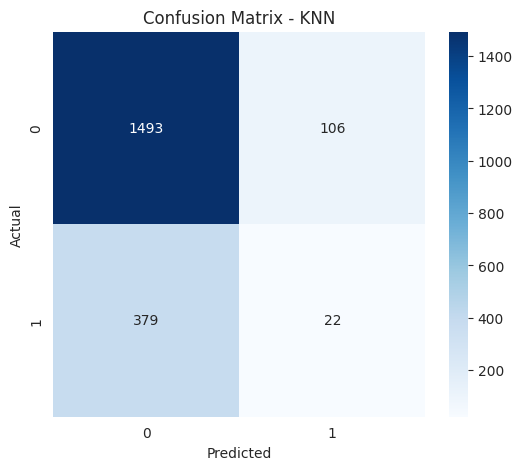



MODEL : SVM

Accuracy Score : 0.7995
ROC AUC Score  : 0.5039

Classification Report:

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1599
           1       0.00      0.00      0.00       401

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



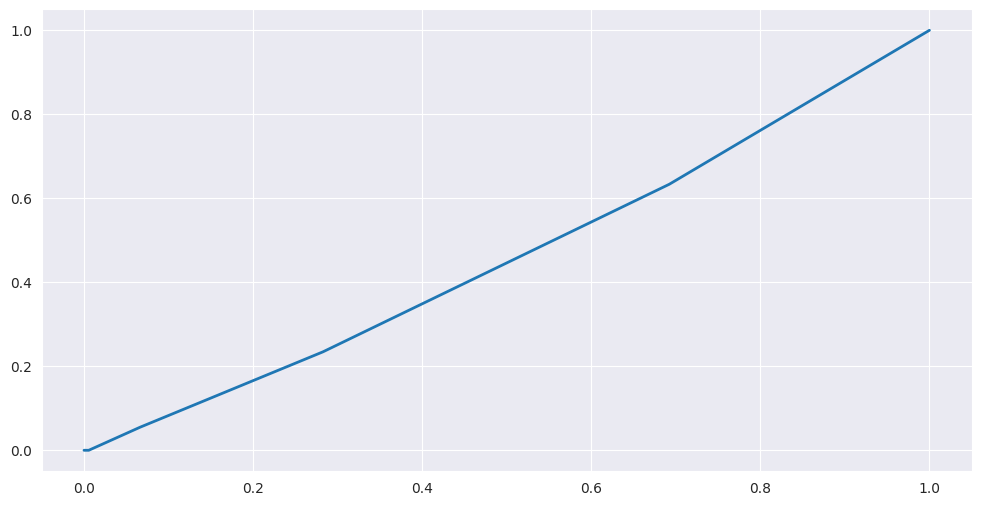

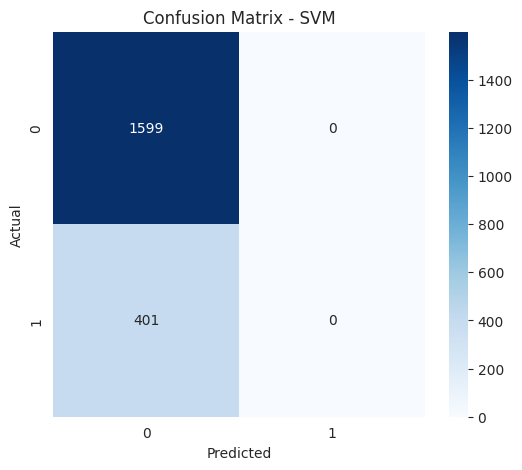



MODEL : XGBoost

Accuracy Score : 0.7890
ROC AUC Score  : 0.4787

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.98      0.88      1599
           1       0.29      0.03      0.06       401

    accuracy                           0.79      2000
   macro avg       0.54      0.51      0.47      2000
weighted avg       0.70      0.79      0.72      2000



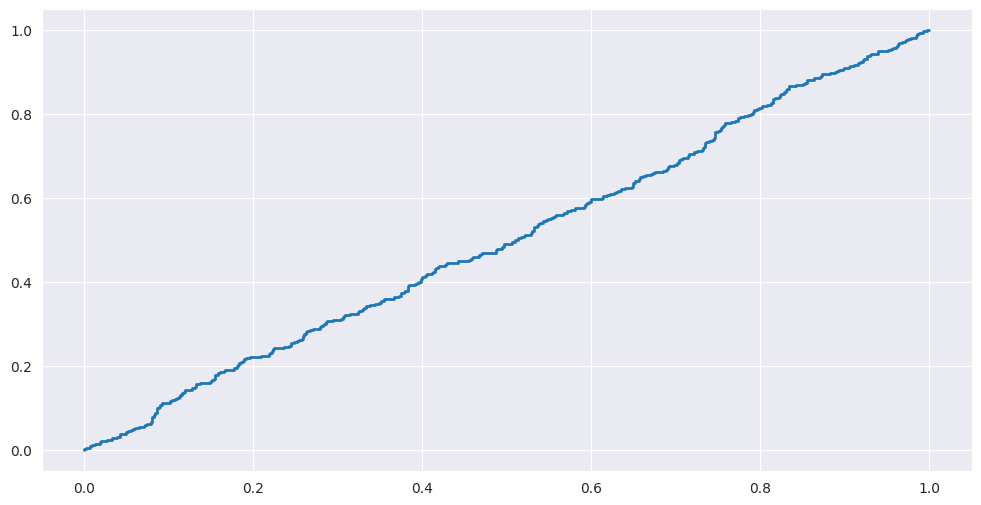

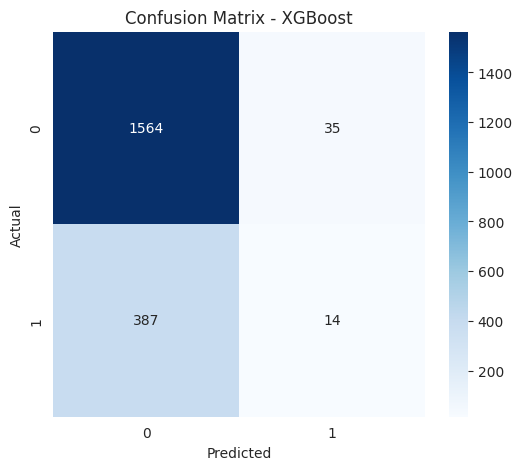

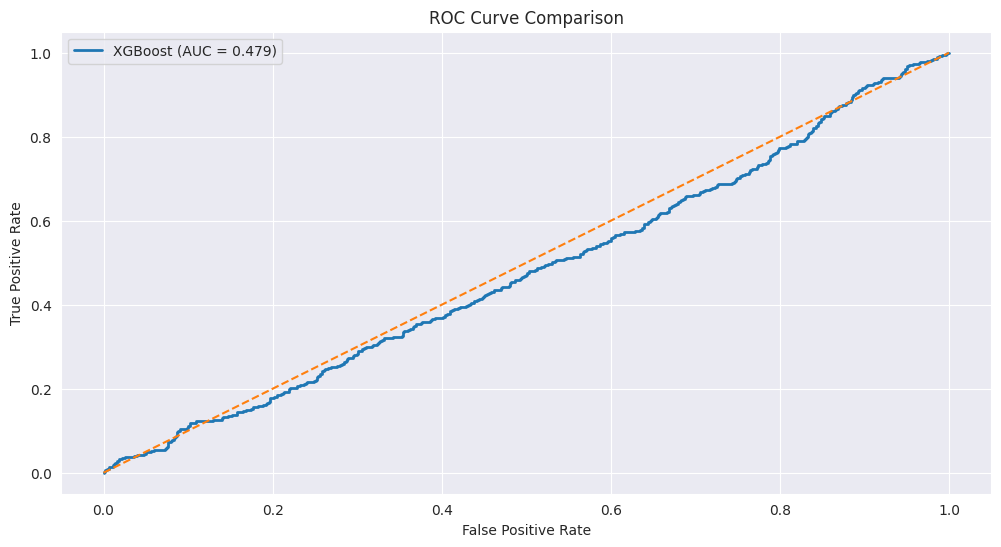



FINAL MODEL COMPARISON
                 Model  Accuracy   ROC_AUC
1        Decision Tree    0.7920  0.520724
3    Gradient Boosting    0.7995  0.512982
2        Random Forest    0.7995  0.504838
5                  SVM    0.7995  0.503870
0  Logistic Regression    0.7975  0.502353
6              XGBoost    0.7890  0.478700
4                  KNN    0.7575  0.462002


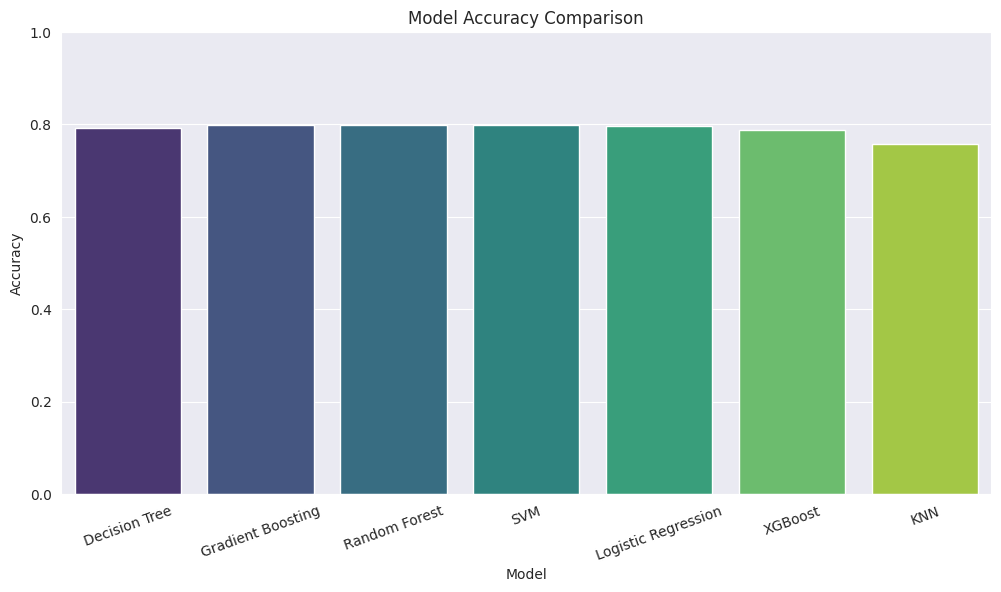

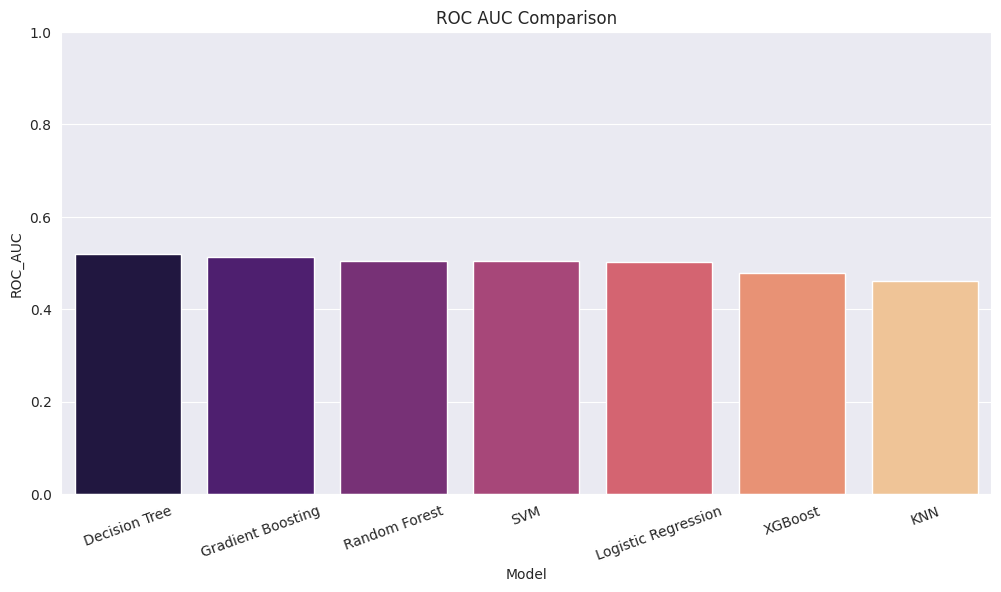

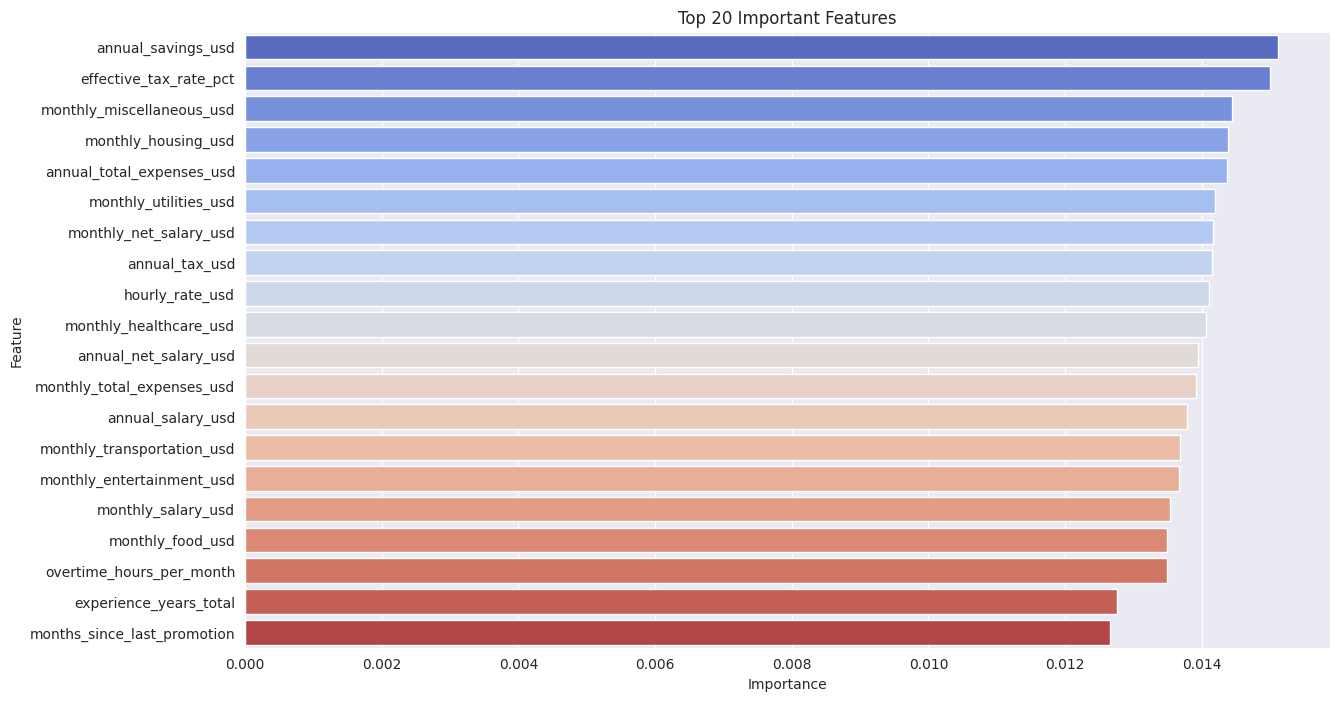


Best model saved successfully!

Sample Predictions:

[0 0 0 0 0]

Machine Learning Pipeline Completed Successfully!


In [15]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve



print("Dataset Shape :", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nMissing Values:\n")
print(df.isnull().sum())

# =========================================================
# TARGET VARIABLE
# =========================================================

# Predict whether employee is actively looking for a job

target_column = 'is_actively_looking'

# =========================================================
# DROP UNNECESSARY COLUMNS
# =========================================================

drop_cols = [
    'employee_id',
    'first_name',
    'last_name'
]

df = df.drop(columns=drop_cols)

# =========================================================
# HANDLE TARGET COLUMN
# =========================================================

# Convert target into numeric

label_encoder_target = LabelEncoder()

df[target_column] = label_encoder_target.fit_transform(df[target_column])

# =========================================================
# SPLIT FEATURES AND TARGET
# =========================================================

X = df.drop(columns=[target_column])

y = df[target_column]

# =========================================================
# IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# =========================================================

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

categorical_cols = X.select_dtypes(include=['object']).columns

print("\nNumerical Columns:\n", numerical_cols)

print("\nCategorical Columns:\n", categorical_cols)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================
# IMPORTANT:
# Splitting BEFORE preprocessing avoids data leakage

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

# =========================================================
# PREPROCESSING PIPELINE
# =========================================================

# Numerical Pipeline
numerical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', StandardScaler())

])

# Categorical Pipeline
categorical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('onehot', OneHotEncoder(handle_unknown='ignore'))

])

# Combine Both
preprocessor = ColumnTransformer(

    transformers=[

        ('num', numerical_transformer, numerical_cols),

        ('cat', categorical_transformer, categorical_cols)

    ]

)

# =========================================================
# MACHINE LEARNING MODELS
# =========================================================

models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(max_depth=8),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(
        probability=True
    ),

    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        random_state=42
    )

}

# =========================================================
# TRAINING + EVALUATION
# =========================================================

results = []

plt.figure(figsize=(12,8))

# =========================================================
# LOOP THROUGH MODELS
# =========================================================

for model_name, model in models.items():

    print("\n")
    print("="*60)
    print("MODEL :", model_name)
    print("="*60)

    # Create Full Pipeline
    clf = Pipeline(steps=[

        ('preprocessor', preprocessor),

        ('model', model)

    ])

    # =====================================================
    # TRAIN MODEL
    # =====================================================

    clf.fit(X_train, y_train)

    # =====================================================
    # PREDICTIONS
    # =====================================================

    y_pred = clf.predict(X_test)

    y_prob = clf.predict_proba(X_test)[:,1]

    # =====================================================
    # ACCURACY
    # =====================================================

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy Score : {accuracy:.4f}")

    # =====================================================
    # ROC AUC SCORE
    # =====================================================

    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"ROC AUC Score  : {roc_auc:.4f}")

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # =====================================================
    # ROC CURVE
    # =====================================================

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{model_name} (AUC = {roc_auc:.3f})'
    )

    # =====================================================
    # STORE RESULTS
    # =====================================================

    results.append({

        'Model': model_name,

        'Accuracy': accuracy,

        'ROC_AUC': roc_auc

    })

# =========================================================
# FINAL ROC CURVE
# =========================================================

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

# =========================================================
# RESULTS DATAFRAME
# =========================================================

results_df = pd.DataFrame(results)

# =========================================================
# SORT RESULTS
# =========================================================

results_df = results_df.sort_values(
    by='ROC_AUC',
    ascending=False
)

print("\n")
print("="*70)
print("FINAL MODEL COMPARISON")
print("="*70)

print(results_df)

# =========================================================
# BARPLOT OF MODEL ACCURACY
# =========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='Accuracy',
    palette='viridis'
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.show()

# =========================================================
# BARPLOT OF ROC AUC
# =========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='ROC_AUC',
    palette='magma'
)

plt.title("ROC AUC Comparison")

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.show()

# =========================================================
# FEATURE IMPORTANCE (RANDOM FOREST)
# =========================================================

rf_pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))

])

rf_pipeline.fit(X_train, y_train)

# =========================================================
# GET FEATURE NAMES
# =========================================================

encoded_cat_columns = rf_pipeline.named_steps[
    'preprocessor'
].transformers_[1][1].named_steps[
    'onehot'
].get_feature_names_out(categorical_cols)

all_features = np.concatenate([
    numerical_cols,
    encoded_cat_columns
])

# =========================================================
# FEATURE IMPORTANCE VALUES
# =========================================================

importance_values = rf_pipeline.named_steps[
    'model'
].feature_importances_

feature_importance_df = pd.DataFrame({

    'Feature': all_features,

    'Importance': importance_values

})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# =========================================================
# TOP 20 IMPORTANT FEATURES
# =========================================================

top_features = feature_importance_df.head(20)

plt.figure(figsize=(14,8))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',
    palette='coolwarm'
)

plt.title("Top 20 Important Features")

plt.show()

# =========================================================
# SAVE BEST MODEL
# =========================================================

import joblib

best_model = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))

])

best_model.fit(X_train, y_train)

joblib.dump(best_model, "employee_attrition_model.pkl")

print("\nBest model saved successfully!")

# =========================================================
# PREDICT ON NEW DATA
# =========================================================

sample_prediction = best_model.predict(X_test.iloc[:5])

print("\nSample Predictions:\n")

print(sample_prediction)

# =========================================================
# END OF PROJECT
# =========================================================

print("\nMachine Learning Pipeline Completed Successfully!")